# 03 - ベースライン：PLS回帰 + GroupKFold CV
**近赤外研究会 スペクトル分析チャレンジ**

## このノートブックの目的
- SNV前処理 + PLS回帰でベースラインモデルを構築する
- GroupKFold CV（樹種グループ）でリークなしに評価する
- LOSO（Leave One Species Out）CVで樹種間転移性能を評価する
- 最終モデルでtestを予測し、提出CSVを生成する

## 0. ライブラリのインポート

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('ライブラリ読み込み完了')

ライブラリ読み込み完了


## 1. データの読み込み

In [18]:
train = pd.read_csv('../data/train_near.csv', encoding='cp932')
test  = pd.read_csv('../data/test_near.csv',  encoding='cp932')

META_COLS   = ['sample number', 'species number', '樹種', '含水率']
SPEC_COLS   = [c for c in train.columns if c not in META_COLS]

X_train = train[SPEC_COLS].values
X_test  = test[SPEC_COLS].values
y_train = train['含水率'].values
groups  = train['樹種'].values

y_min, y_max = y_train.min(), y_train.max()

print(f'Train : {X_train.shape}')
print(f'Test  : {X_test.shape}')
print(f'含水率範囲 : {y_min:.2f} – {y_max:.2f} %')

Train : (1322, 1555)
Test  : (550, 1555)
含水率範囲 : 0.84 – 298.58 %


## 2. 前処理（SNV）

In [19]:
def snv(X):
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1, keepdims=True)
    return (X - mean) / std

X_train_snv = snv(X_train)
X_test_snv  = snv(X_test)

print('SNV前処理完了')

SNV前処理完了


## 3. GroupKFold CV

同一樹種がtrain/valに混在しないよう、**樹種でグループ化**したKFoldを使う。  
random KFoldは樹種内リークが発生するため使用禁止。

In [20]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

N_COMPONENTS = 3
N_SPLITS     = 5

gkf = GroupKFold(n_splits=N_SPLITS)
oof_preds = np.zeros(len(y_train))

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train_snv, y_train, groups)):
    X_tr, X_val = X_train_snv[tr_idx], X_train_snv[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    pls = PLSRegression(n_components=N_COMPONENTS)
    pls.fit(X_tr, y_tr)
    pred = pls.predict(X_val).ravel()

    fold_rmse = rmse(y_val, pred)
    val_species = set(groups[val_idx])
    print(f'Fold {fold+1}  val樹種: {val_species}  RMSE: {fold_rmse:.4f}')
    oof_preds[val_idx] = pred

cv_rmse = rmse(y_train, oof_preds)
print(f'\nGroupKFold CV RMSE : {cv_rmse:.4f}')

Fold 1  val樹種: {'トチ', 'チェリー'}  RMSE: 24.8765
Fold 2  val樹種: {'クリ', 'ヒノキ'}  RMSE: 13.0567
Fold 3  val樹種: {'ホワイトオーク', 'ベイスギ', 'ベイマツ'}  RMSE: 48.3922
Fold 4  val樹種: {'イチョウ', 'ウォールナット', 'ウエンジ'}  RMSE: 22.6989
Fold 5  val樹種: {'ナラ', 'スプルース', '米ヒバ'}  RMSE: 15.8704

GroupKFold CV RMSE : 27.8477


## 4. LOSO CV（Leave One Species Out）

1樹種ずつをvalにして残りでtrainする。  
LBスコアの代理として最も信頼性が高い評価方法。

In [21]:
species_list = train['樹種'].unique()
loso_scores = {}

for species in species_list:
    val_mask = groups == species
    tr_mask  = ~val_mask

    pls = PLSRegression(n_components=N_COMPONENTS)
    pls.fit(X_train_snv[tr_mask], y_train[tr_mask])
    pred = pls.predict(X_train_snv[val_mask]).ravel()

    loso_scores[species] = rmse(y_train[val_mask], pred)

loso_series = pd.Series(loso_scores).sort_values()
print('LOSO RMSE（樹種別）:')
print(loso_series.round(2).to_string())
print(f'\nLOSO mean   : {loso_series.mean():.4f}')
print(f'LOSO median : {loso_series.median():.4f}')

LOSO RMSE（樹種別）:
スプルース       5.05
ベイマツ        6.51
クリ         10.83
トチ         12.70
ウォールナット    14.19
米ヒバ        14.41
ヒノキ        15.07
ホワイトオーク    15.55
イチョウ       18.20
ナラ         23.21
ウエンジ       34.62
チェリー       35.90
ベイスギ       71.33

LOSO mean   : 21.3526
LOSO median : 15.0709


## 5. 予測分布の確認（OOF）

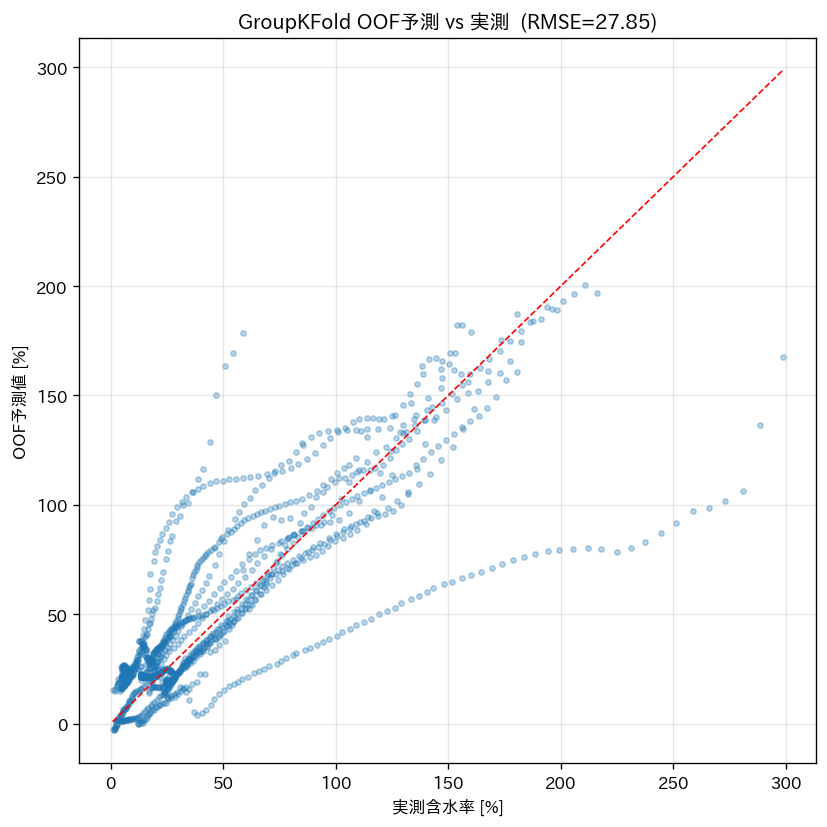

In [22]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_train, oof_preds, alpha=0.3, s=10)
ax.plot([y_min, y_max], [y_min, y_max], 'r--', linewidth=1)
ax.set_xlabel('実測含水率 [%]')
ax.set_ylabel('OOF予測値 [%]')
ax.set_title(f'GroupKFold OOF予測 vs 実測  (RMSE={cv_rmse:.2f})')
plt.tight_layout()
plt.show()

## 6. 最終モデルの学習・予測・提出CSV生成

trainデータ全体で学習し、testを予測する。  
予測値はtrainの含水率範囲にclipして外挿を防ぐ。

In [23]:
pls_final = PLSRegression(n_components=N_COMPONENTS)
pls_final.fit(X_train_snv, y_train)

y_pred = pls_final.predict(X_test_snv).ravel()
y_pred_clipped = np.clip(y_pred, y_min, y_max)

print(f'予測値（clip前）: min={y_pred.min():.2f}, max={y_pred.max():.2f}')
print(f'予測値（clip後）: min={y_pred_clipped.min():.2f}, max={y_pred_clipped.max():.2f}')

fname = f'../submissions/submission_pls{N_COMPONENTS}_snv.csv'
submission = pd.DataFrame({
    'sample number': test['sample number'],
    '含水率': y_pred_clipped
})
submission.to_csv(fname, index=False, header=False)
print(f'\n提出CSV保存完了: {fname}')
print(submission.head())

予測値（clip前）: min=-7.90, max=167.31
予測値（clip後）: min=0.84, max=167.31

提出CSV保存完了: ../submissions/submission_pls3_snv.csv
   sample number         含水率
0             95  167.307957
1             96  142.248626
2             97  134.390111
3             98  133.162668
4             99  130.387671


## 7. まとめ

| 項目 | 値 |
|------|----|
| 前処理 | SNV |
| モデル | PLS（n_components=3） |
| CV方法 | GroupKFold（k=5、樹種グループ） |
| GroupKFold RMSE | （実行後に記入） |
| LOSO mean RMSE | （実行後に記入） |
| clip範囲 | [y_min, y_max] |

### 次のステップ
- EPOの実装による干渉除去の試行
- コードの3分割整備（Preprocessing / Learning / Predicting）

In [24]:
# PLS n_components 感度確認（LOSO）
# n=3がベストか、1や2の方が転移するか確認する
print('n_pls  LOSO_mean  LOSO_median')
print('-----  ---------  -----------')

for n in [1, 2, 3, 4, 5]:
    species_all = np.unique(groups)
    scores = {}
    for sp in species_all:
        val_mask = groups == sp
        tr_mask  = ~val_mask
        pls = PLSRegression(n_components=n)
        pls.fit(X_train_snv[tr_mask], y_train[tr_mask])
        scores[sp] = rmse(y_train[val_mask], pls.predict(X_train_snv[val_mask]).ravel())
    s = pd.Series(scores)
    print(f'  {n:2d}     {s.mean():6.2f}       {s.median():6.2f}')

n_pls  LOSO_mean  LOSO_median
-----  ---------  -----------
   1      29.45        23.46
   2      20.83        15.42
   3      21.35        15.07
   4      22.65        16.84
   5      30.13        22.70
